<a href="https://colab.research.google.com/github/rakshitha01-a11y/house-price-prediction/blob/main/HousePricePrediction_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
print("HousePricePrediction.csv)")
uploaded = files.upload()

HousePricePrediction.csv)


Saving HousePricePrediction.xlsx to HousePricePrediction.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("HousePricePrediction.xlsx")

print(df.head())

   Id  MSSubClass  LotArea  OverallQual  OverallCond  YearBuilt  YearRemodAdd  \
0   1          60     8450            7            5       2003          2003   
1   2          20     9600            6            8       1976          1976   
2   3          60    11250            7            5       2001          2002   
3   4          70     9550            7            5       1915          1970   
4   5          60    14260            8            5       2000          2000   

   BsmtFinSF1  BsmtUnfSF  TotalBsmtSF  ...  WoodDeckSF  OpenPorchSF  \
0         706        150          856  ...           0           61   
1         978        284         1262  ...         298            0   
2         486        434          920  ...           0           42   
3         216        540          756  ...           0           35   
4         655        490         1145  ...         192           84   

   EnclosedPorch  3SsnPorch  ScreenPorch  PoolArea  MiscVal  MoSold  YrSold  \
0      

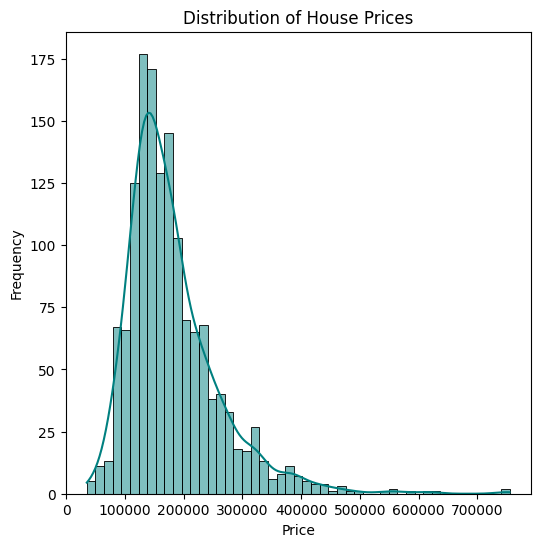

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.histplot(df['SalePrice'], kde=True, color='teal')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

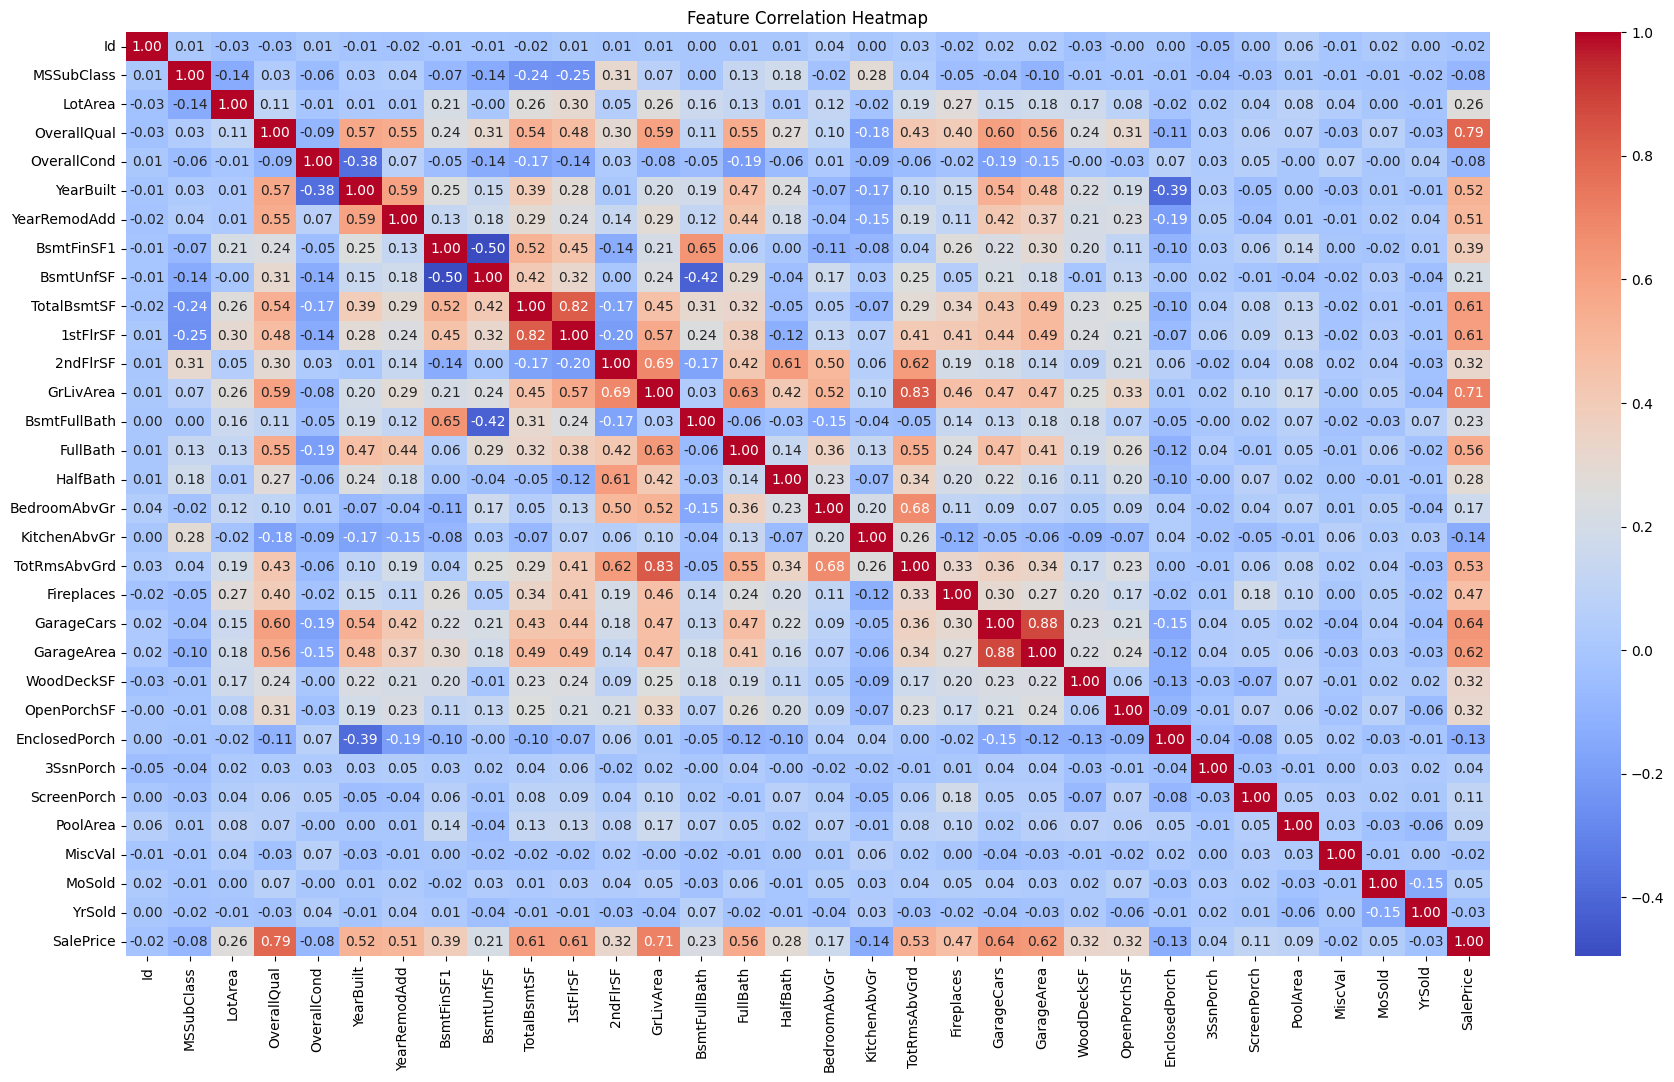

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,12))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print("\nStep 3: Training Multiple Models...")

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}


Step 3: Training Multiple Models...


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

model_results = []

for name, model in models.items():

    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('regressor', model)])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    model_results.append({"Model": name, "R2 Score": r2, "MAE": mae, "RMSE": rmse})
    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [ ]:
results_df = pd.DataFrame(model_results).sort_values(by='R2 Score', ascending=False)
print("\n--- MODEL PERFORMANCE COMPARISON ---")
print(results_df)


--- MODEL PERFORMANCE COMPARISON ---
               Model  R2 Score           MAE          RMSE
2  Gradient Boosting  0.897876  17396.392475  27987.876681
1      Random Forest  0.887953  18059.386747  29316.183601
0  Linear Regression  0.818428  22961.103233  37319.100407


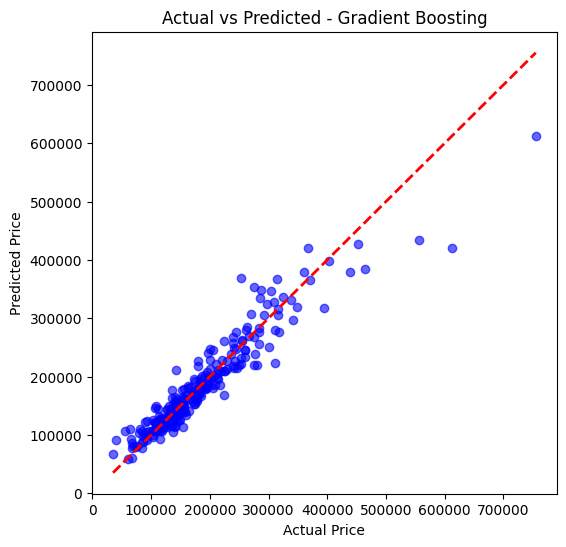

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model = Pipeline(steps=[('preprocessor', preprocessor),
                             ('regressor', models[best_model_name])])
best_model.fit(X_train, y_train)
final_predictions = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, final_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Actual vs Predicted - {best_model_name}')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

In [ ]:
!pip install plotly openpyxl

import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_excel("HousePricePrediction.xlsx")

fig = px.scatter_3d(
    df,
    x="GrLivArea",
    y="TotRmsAbvGrd",
    z="SalePrice",
    color="SalePrice",
    hover_data=df.columns,
    title="Interactive 3D House Price Visualization"
)

fig.update_traces(marker=dict(size=5))

fig.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.8881005786944708


In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test ,
    pred,
    alpha=0.6
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

NameError: name 'y_test' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
import pandas as pd
import plotly.express as px

df = pd.read_excel("HousePricePrediction.xlsx")

fig = px.scatter_3d(
    df,
    x="GrLivArea",      # Changed from "squareMeters"
    y="TotRmsAbvGrd",   # Changed from "numberOfRooms"
    z="YearBuilt",      # Changed from "numberOfFloors" to "YearBuilt" as a proxy
    size="SalePrice",   # Changed from "price"
    color="SalePrice",  # Changed from "price"
    hover_data=df.columns,
    title="3D Bubble Plot - House Prices"
)

fig.show()

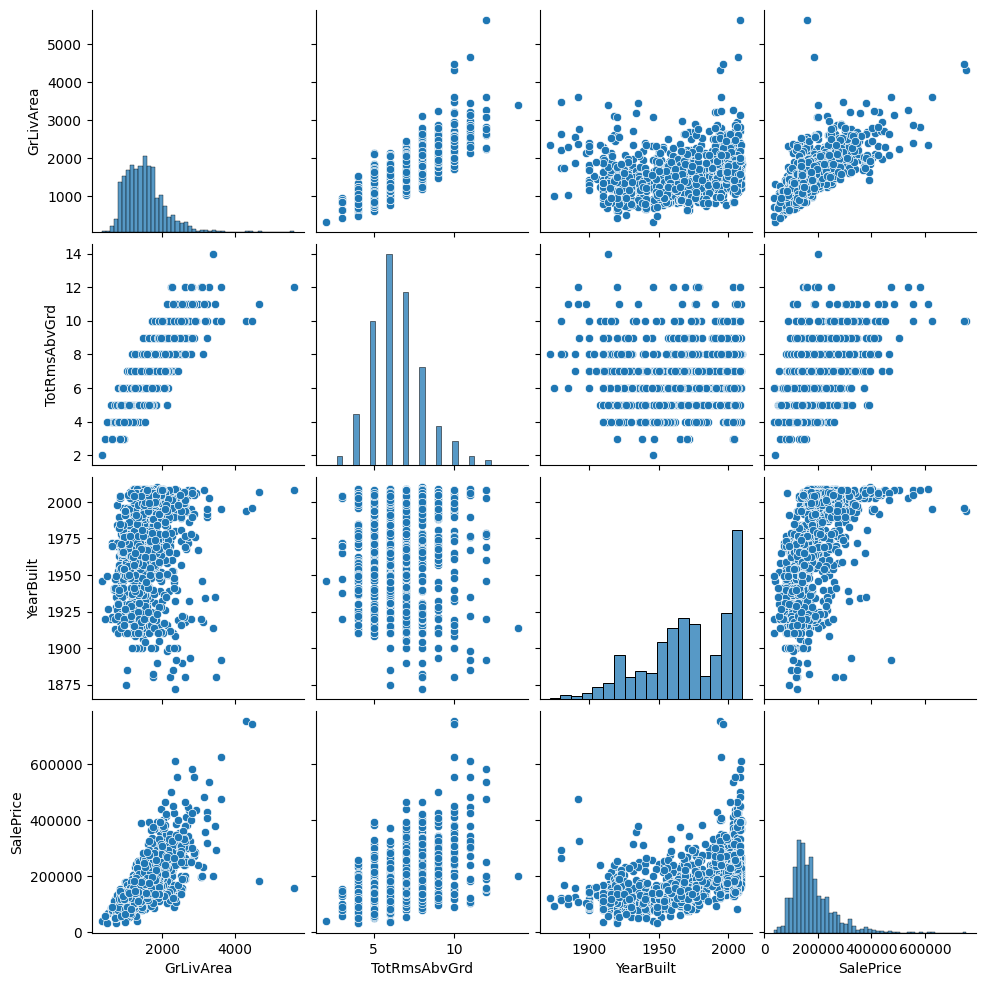

In [ ]:
import seaborn as sns
sns.pairplot(
    df[[
        "GrLivArea",
        "TotRmsAbvGrd",
        "YearBuilt",
        "SalePrice"
    ]]
)
plt.show()

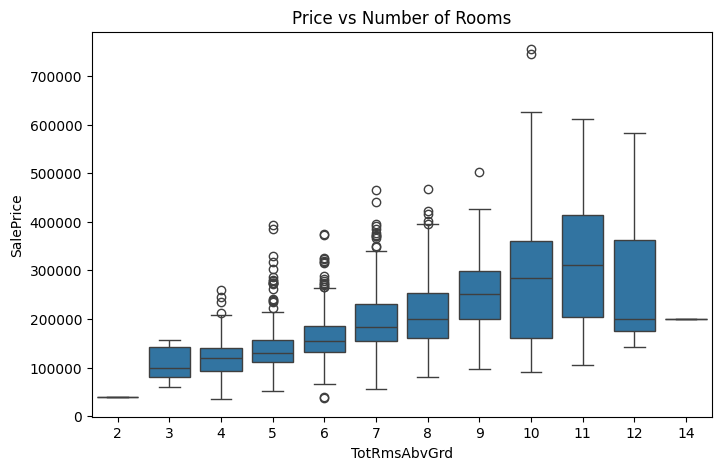

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["TotRmsAbvGrd"], # Corrected from "numberOfRooms"
    y=df["SalePrice"]   # Corrected from "price"
)

plt.title("Price vs Number of Rooms")
plt.show()

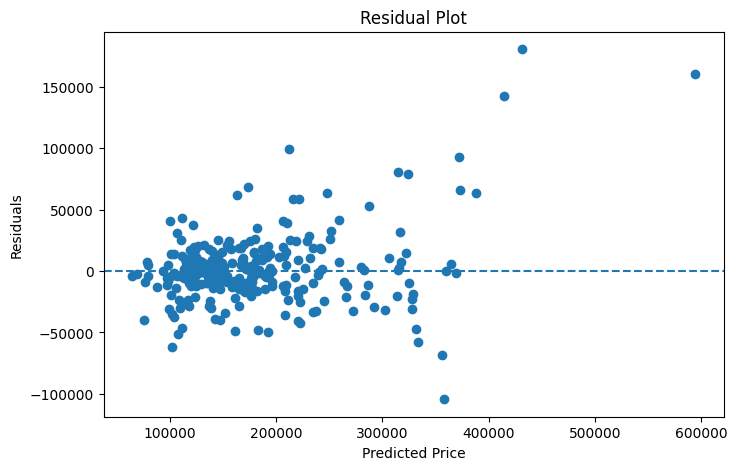

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

residuals = y_test - pred

plt.figure(figsize=(8,5))

plt.scatter(pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

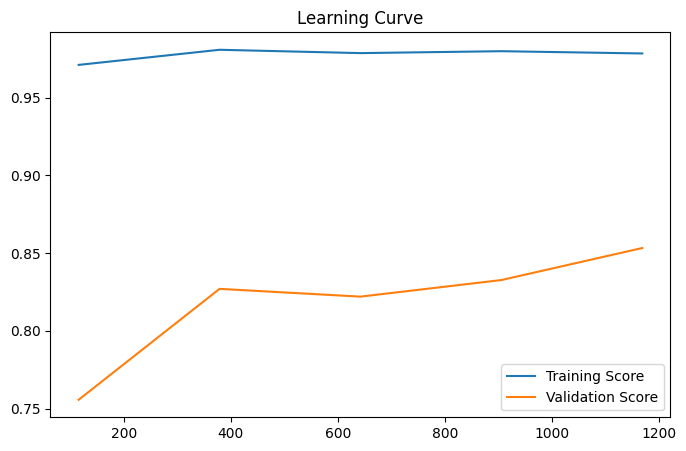

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestRegressor(),
    X, y,
    cv=5
)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    np.mean(train_scores, axis=1),
    label="Training Score"
)

plt.plot(
    train_sizes,
    np.mean(test_scores, axis=1),
    label="Validation Score"
)

plt.legend()
plt.title("Learning Curve")
plt.show()

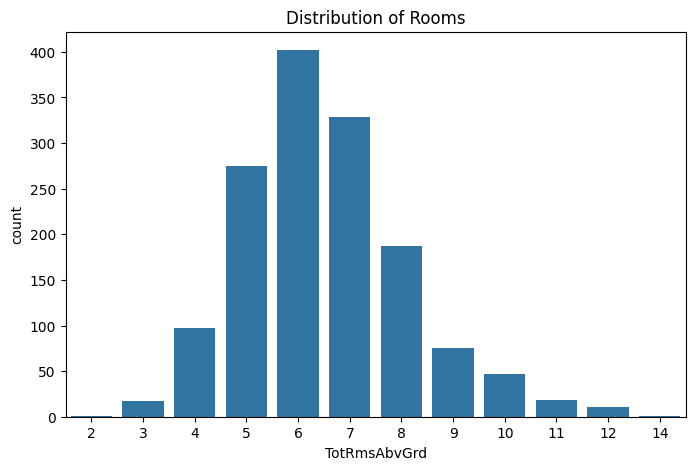

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["TotRmsAbvGrd"] # Corrected column name from "numberOfRooms"
)

plt.title("Distribution of Rooms")
plt.show()

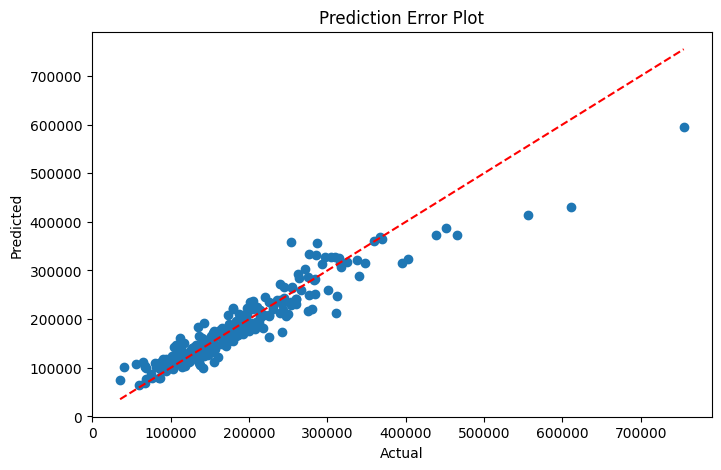

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction Error Plot")

plt.show()